# AutoCog simulated-data analysis

This notebook reads the simulated export directly and compares observed choices with tallying and WADD predictions.

In [1]:
from pathlib import Path
import ast
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 50
zip_path = Path("../simulated_data.zip")
with zipfile.ZipFile(zip_path) as zf:
    with zf.open("simulated_data/regular/basic_data/trial.csv") as f:
        trials = pd.read_csv(f)

for column in ["validities", "option_a_ratings", "option_b_ratings"]:
    trials[column] = trials[column].apply(ast.literal_eval)

trials.head()

,id,participant_id,trial_index,source_pair_index,presentation_swapped,left_option_id,right_option_id,validities,option_a_ratings,option_b_ratings,answer,complete,score
0,3,1,33,3,True,option_b,option_a,"[0.95, 0.85, 0.6, 0.55, 0.5]","[1, 0, 0, 0, 1]","[0, 1, 1, 1, 0]",option_b,True,1.0
1,1,1,14,4,False,option_a,option_b,"[0.95, 0.85, 0.6, 0.55, 0.5]","[1, 0, 1, 0, 0]","[0, 1, 0, 1, 0]",option_a,True,1.0
2,268,6,43,3,True,option_b,option_a,"[0.95, 0.85, 0.6, 0.55, 0.5]","[1, 0, 0, 0, 1]","[0, 1, 1, 1, 0]",option_b,True,1.0
3,2,1,40,0,False,option_a,option_b,"[0.95, 0.85, 0.6, 0.55, 0.5]","[0, 0, 1, 1, 1]","[1, 1, 0, 0, 0]",option_a,True,1.0
4,5,1,34,4,False,option_a,option_b,"[0.95, 0.85, 0.6, 0.55, 0.5]","[1, 0, 1, 0, 0]","[0, 1, 0, 1, 0]",option_a,True,1.0


In [2]:
def tally_prediction(row):
    a_wins = sum(a > b for a, b in zip(row.option_a_ratings, row.option_b_ratings))
    b_wins = sum(b > a for a, b in zip(row.option_a_ratings, row.option_b_ratings))
    if a_wins > b_wins:
        return "option_a"
    if b_wins > a_wins:
        return "option_b"
    return "tie"

def wadd_prediction(row):
    a_score = sum(v * a for v, a in zip(row.validities, row.option_a_ratings))
    b_score = sum(v * b for v, b in zip(row.validities, row.option_b_ratings))
    if a_score > b_score:
        return "option_a"
    if b_score > a_score:
        return "option_b"
    return "tie"

trials["tally_prediction"] = trials.apply(tally_prediction, axis=1)
trials["wadd_prediction"] = trials.apply(wadd_prediction, axis=1)
trials["matches_tally"] = trials.answer == trials.tally_prediction
trials["matches_wadd"] = trials.answer == trials.wadd_prediction
summary = trials.groupby("source_pair_index").agg(
    trials=("id", "count"),
    option_a_choices=("answer", lambda x: (x == "option_a").sum()),
    option_b_choices=("answer", lambda x: (x == "option_b").sum()),
    tally_prediction=("tally_prediction", "first"),
    wadd_prediction=("wadd_prediction", "first"),
    mean_matches_tally=("matches_tally", "mean"),
    mean_matches_wadd=("matches_wadd", "mean"),
)
summary

,trials,option_a_choices,option_b_choices,tally_prediction,wadd_prediction,mean_matches_tally,mean_matches_wadd
source_pair_index,,,,,,,
0,60,60,0,option_a,option_b,1.0,0.0
1,60,0,60,option_b,option_a,1.0,0.0
2,60,60,0,option_a,option_a,1.0,1.0
3,60,0,60,option_b,option_b,1.0,1.0
4,60,60,0,tie,option_a,0.0,1.0
5,60,0,60,tie,option_b,0.0,1.0
6,60,60,0,option_a,option_a,1.0,1.0
7,60,0,60,option_b,option_b,1.0,1.0
8,60,60,0,option_a,option_a,1.0,1.0


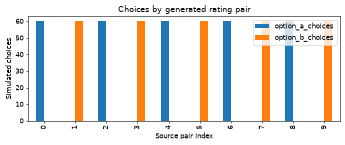

In [3]:
ax = summary[["option_a_choices", "option_b_choices"]].plot(kind="bar", figsize=(7, 3))
ax.set_xlabel("Source pair index")
ax.set_ylabel("Simulated choices")
ax.set_title("Choices by generated rating pair")
plt.tight_layout()

The simulated bots chose the left displayed option by design, which exercises both saved option identities because presentation order alternates across trials. The exported rows contain 12 bots x 50 trials = 600 completed choices, with reconstruction fields for validities, original ratings, presentation order, and selected option.